In [2]:
pip install imbalanced-learn lightgbm optuna

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
  Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
  Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
  Using cached mako-1.3.12-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.12.0 requires aiohttp<4, which is not installed.
mlflow 3.12.0 requires docker<8,>=4.0.0, which is not installed.
mlflow 3.12.0 requires Flask<4, which is not installed.
mlflow 3.12.0 requires Flask-CORS<7, which is not installed.
mlflow 3.12.0 requires graphene<4, which is not installed.
mlflow 3.12.0 requires huey<3,>=2.5.4, which is not installed.
mlflow 3.12.0 requires mlflow-tracing==3.12.0, which is not installed.
mlflow 3.12.0 requires skops<1, which is not installed.
mlflow 3.12.0 requires waitress<4; platform_system == "Windows", which is not installed.
mlflow 3.12.0 requires cryptography<47,>=43.0.0, but you have cryptography 48.0.0 which is incompatible.
mlflow 3.12.0 requires pyarrow<24,>=4.0.0, but you have pyarrow 24.0.0 which is incompatible.

[notice] A new release of pip available: 22.2.2

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb

# Load data
df = pd.read_csv('../data/processed/features.csv')
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data loaded.")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class imbalance — No Churn: {(y==0).sum()} | Churn: {(y==1).sum()}")

# Baseline
baseline = joblib.load('../outputs/model.pkl')
base_proba = baseline.predict_proba(np.array(X_test))[:, 1]
base_pred = baseline.predict(np.array(X_test))
base_auc = roc_auc_score(y_test, base_proba)
print(f"\nBaseline AUC-ROC: {base_auc:.4f}")
print(classification_report(y_test, base_pred, target_names=['Retained','Churned']))

# SMOTETomek
print("Applying SMOTETomek...")
smt = SMOTETomek(random_state=42)
X_bal, y_bal = smt.fit_resample(X_train, y_train)
X_bal_np = np.array(X_bal)
y_bal_np = np.array(y_bal)
X_test_np = np.array(X_test)
print(f"Balanced: {dict(pd.Series(y_bal_np).value_counts())}")

Data loaded.
Train: (5634, 32) | Test: (1409, 32)
Class imbalance — No Churn: 5174 | Churn: 1869

Baseline AUC-ROC: 0.8437
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Applying SMOTETomek...
Balanced: {0: np.int64(3819), 1: np.int64(3819)}


Logistic Regression AUC: 0.8422
Random Forest AUC:       0.8397
XGBoost AUC:             0.8381
LightGBM AUC:            0.8355
Ensemble AUC:            0.8393

Optimal Threshold: 0.279

Final XGBoost + SMOTE Report:
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1035
     Churned       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- MODEL COMPARISON ---
              Model  AUC-ROC
   Baseline XGBoost 0.843651
Logistic Regression 0.842179
      Random Forest 0.839672
           Ensemble 0.839282
    XGBoost + SMOTE 0.838141
   LightGBM + SMOTE 0.835475


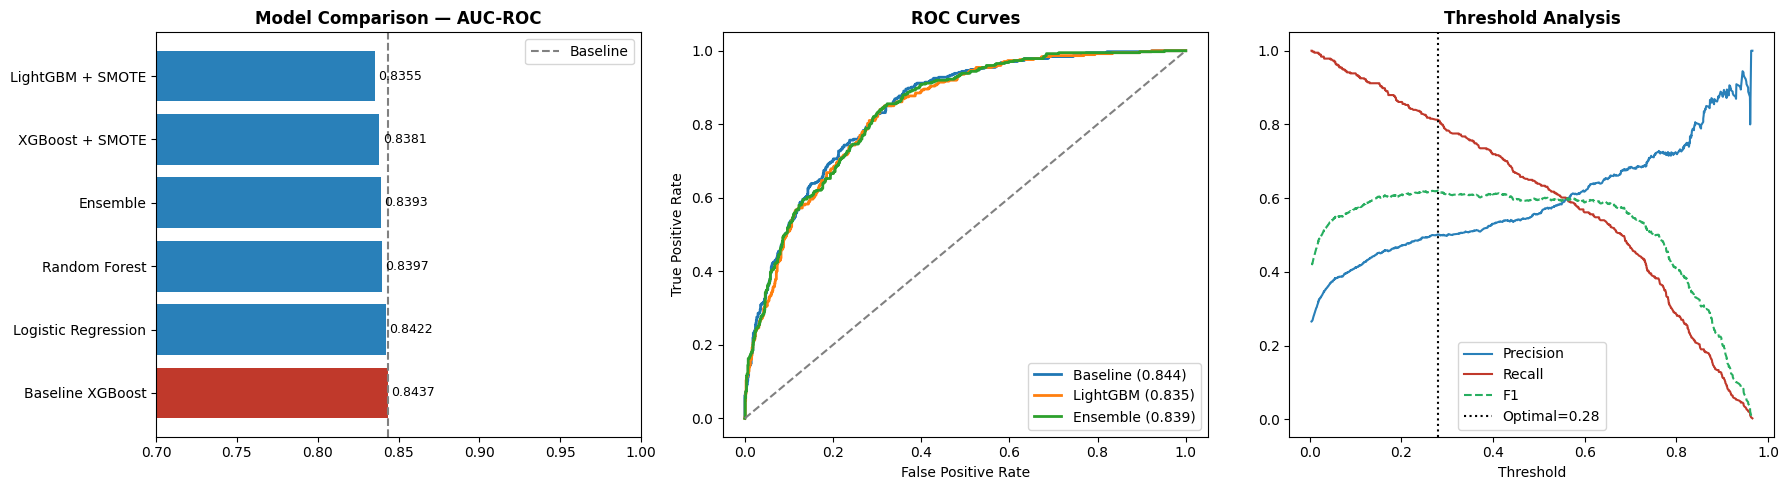


Notebook 07 Complete.
Model saved: outputs/model.pkl
Best AUC: 0.8437


In [6]:
# Logistic Regression
scaler = StandardScaler()
X_bal_scaled = scaler.fit_transform(X_bal_np)
X_test_scaled = scaler.transform(X_test_np)

lr = LogisticRegression(random_state=42, max_iter=1000, C=0.1)
lr.fit(X_bal_scaled, y_bal_np)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
print(f"Logistic Regression AUC: {lr_auc:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=6,
                             random_state=42, n_jobs=-1)
rf.fit(X_bal_np, y_bal_np)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_np)[:, 1])
print(f"Random Forest AUC:       {rf_auc:.4f}")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(X_bal_np, y_bal_np)
xgb_proba = xgb_model.predict_proba(X_test_np)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f"XGBoost AUC:             {xgb_auc:.4f}")

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    num_leaves=40, random_state=42, verbose=-1
)
lgb_model.fit(X_bal_np, y_bal_np)
lgb_proba = lgb_model.predict_proba(X_test_np)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_proba)
print(f"LightGBM AUC:            {lgb_auc:.4f}")

# Ensemble
ensemble_proba = (3*xgb_proba + 3*lgb_proba + 1*rf_proba) / 7
ensemble_auc = roc_auc_score(y_test, ensemble_proba)
print(f"Ensemble AUC:            {ensemble_auc:.4f}")

# Threshold tuning
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, xgb_proba)
f1_scores = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
best_thresh = float(thresholds[np.argmax(f1_scores[:-1])])
final_pred = (xgb_proba >= best_thresh).astype(int)

print(f"\nOptimal Threshold: {best_thresh:.3f}")
print(f"\nFinal XGBoost + SMOTE Report:")
print(classification_report(y_test, final_pred, target_names=['Retained','Churned']))

# Comparison table
results = pd.DataFrame({
    'Model': ['Baseline XGBoost', 'Logistic Regression',
              'Random Forest', 'XGBoost + SMOTE',
              'LightGBM + SMOTE', 'Ensemble'],
    'AUC-ROC': [base_auc, lr_auc, rf_auc, xgb_auc, lgb_auc, ensemble_auc]
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("\n--- MODEL COMPARISON ---")
print(results.to_string(index=False))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results['Model'], results['AUC-ROC'],
             color=['#C0392B' if 'Baseline' in m else '#2980B9'
                    for m in results['Model']])
axes[0].set_xlim(0.7, 1.0)
axes[0].set_title('Model Comparison — AUC-ROC', fontweight='bold')
axes[0].axvline(base_auc, color='gray', linestyle='--', label='Baseline')
axes[0].legend()
for i, v in enumerate(results['AUC-ROC']):
    axes[0].text(v+0.002, i, f'{v:.4f}', va='center', fontsize=9)

for name, proba in [('Baseline', base_proba),
                     ('LightGBM', lgb_proba),
                     ('Ensemble', ensemble_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, lw=2,
                 label=f'{name} ({roc_auc_score(y_test, proba):.3f})')
axes[1].plot([0,1],[0,1],'gray',linestyle='--')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

axes[2].plot(thresholds, precision_arr[:-1], label='Precision', color='#2980B9')
axes[2].plot(thresholds, recall_arr[:-1], label='Recall', color='#C0392B')
axes[2].plot(thresholds, f1_scores[:-1], label='F1', color='#27AE60', linestyle='--')
axes[2].axvline(best_thresh, color='black', linestyle=':',
                label=f'Optimal={best_thresh:.2f}')
axes[2].set_title('Threshold Analysis', fontweight='bold')
axes[2].set_xlabel('Threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best model
joblib.dump(xgb_model, '../outputs/model.pkl')

pred_df = pd.DataFrame({
    'churn_probability': xgb_proba,
    'predicted_churn': final_pred,
    'actual_churn': y_test.values,
    'tenure': X_test['tenure'].values,
    'MonthlyCharges': X_test['MonthlyCharges'].values,
    'tenure_group': X_test['tenure_group'].values,
    'support_score': X_test['support_score'].values
})
pred_df['risk_tier'] = pd.cut(
    pred_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
pred_df.to_csv('../outputs/predictions.csv', index=False)

print("\nNotebook 07 Complete.")
print(f"Model saved: outputs/model.pkl")
print(f"Best AUC: {max(base_auc, xgb_auc, lgb_auc, ensemble_auc):.4f}")